In [2]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

In [3]:
# Configuration
SEASONAL_PERIOD = 52
MIN_WEEKS = 104
FORECAST_HORIZON = 12
ALPHA = 0.2   # 80% interval → P10 / P90


In [4]:
# Load data
orders = pd.read_csv("../output/orders.csv")
print(orders.columns.tolist())


['order_id', 'order_date', 'sku_id', 'region', 'payment_type', 'delivery_days', 'delivery_status', 'campaign_applied', 'order_quantity']


In [5]:
orders.head()

,order_id,order_date,sku_id,region,payment_type,delivery_days,delivery_status,campaign_applied,order_quantity
0,ORD000000104,0,SKU0002,south,COD,4,DELIVERED,False,1
1,ORD000000103,0,SKU0002,south,COD,3,DELIVERED,False,1
2,ORD000000102,0,SKU0002,south,COD,2,DELIVERED,False,1
3,ORD000000101,0,SKU0002,south,COD,1,DELIVERED,False,1
4,ORD000000100,0,SKU0002,north,PREPAID,5,DELIVERED,False,1


In [ ]:
# Constants for column names
QTY_COL = "order_quantity"
CAMPAIGN_COL = "campaign_applied"


# Parse order_date explicitly (your data is integer day index)
orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    unit="D",
    origin="unix"
)

# Weekly aggregation (calendar-safe, no integer division)
weekly = (
    orders
    .set_index("order_date")
    .groupby("sku_id")
    .resample("W-SUN")
    .agg(
        weekly_qty=(QTY_COL, "sum"),
        campaign_intensity=(CAMPAIGN_COL, "mean")
    )
    .reset_index()
)

# Rename for clarity & consistency
weekly.rename(columns={"order_date": "week"}, inplace=True)
weekly = weekly.sort_values(["sku_id", "week"]).reset_index(drop=True)

weekly.head()

C:\Users\ACER\AppData\Local\Temp\ipykernel_23224\2750768797.py:18: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .agg(


,sku_id,week,weekly_qty,campaign_intensity
0,SKU0001,1970-01-04,258,0.000000
1,SKU0001,1970-01-11,710,0.336149
2,SKU0001,1970-01-18,2259,1.000000
3,SKU0001,1970-01-25,2070,0.948678
4,SKU0001,1970-02-01,845,0.533237


In [8]:
# Select SKU with longest history (robust & explicit)
sku_id = (
    weekly.groupby("sku_id")["week"]
    .count()
    .sort_values(ascending=False)
    .index[0]
)

sku_df = (
    weekly[weekly["sku_id"] == sku_id]
    .sort_values("week")
    .reset_index(drop=True)
)

print("Selected SKU:", sku_id)
print("Total weeks:", len(sku_df))


Selected SKU: SKU0001
Total weeks: 105


In [9]:
# Chronological split by position, not by week number
weeks = sku_df["week"].unique()
split_idx = int(len(weeks) * 0.8)

train_weeks = weeks[:split_idx]
val_weeks = weeks[split_idx:]

train_df = sku_df[sku_df["week"].isin(train_weeks)].copy()
val_df = sku_df[sku_df["week"].isin(val_weeks)].copy()

print("Train weeks:", len(train_df))
print("Validation weeks:", len(val_df))


Train weeks: 84
Validation weeks: 21


In [10]:
# ADF test on raw and log1p-transformed data
adf_raw = adfuller(train_df["weekly_qty"])
adf_log = adfuller(np.log1p(train_df["weekly_qty"]))

print("ADF p-value (raw):", round(adf_raw[1], 4))
print("ADF p-value (log1p):", round(adf_log[1], 4))


ADF p-value (raw): 0.0001
ADF p-value (log1p): 0.0001


In [12]:
y_train = np.log1p(train_df["weekly_qty"])
exog_train = train_df[["campaign_intensity"]]

model = SARIMAX(
    y_train,
    exog=exog_train,
    order=(1, 0, 1),
    seasonal_order=(0, 1, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                          weekly_qty   No. Observations:                   84
Model:             SARIMAX(1, 0, 1)x(0, 1, [], 52)   Log Likelihood                  49.028
Date:                             Tue, 23 Dec 2025   AIC                            -90.056
Time:                                     11:33:46   BIC                            -84.452
Sample:                                          0   HQIC                           -88.263
                                              - 84                                         
Covariance Type:                               opg                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
campaign_intensity     1.4858      0.087     17.092      0.000       1.315       1.656
ar.L1                  0.0496      0.580      0.086      0.932      -1.086       1.185
ma.L1                  0.4740      0.171      2.767      0.006       0.138       0.810
sigma2                 0.0022      0.000      7.821      0.000       0.002       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.75   Jarque-Bera (JB):               217.06
Prob(Q):                              0.39   Prob(JB):                         0.00
Heteroskedasticity (H):               0.08   Skew:                             2.95
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
# Validation forecast using the trained SARIMAX
exog_val = val_df[["campaign_intensity"]]

pred_val = results.get_forecast(
    steps=len(val_df),
    exog=exog_val
)

ci_val = pred_val.conf_int(alpha=0.2)  # 80% interval

val_df["p50"] = np.expm1(pred_val.predicted_mean.values)
val_df["p10"] = np.expm1(ci_val.iloc[:, 0].values)
val_df["p90"] = np.expm1(ci_val.iloc[:, 1].values)

val_df.head()


,sku_id,week,weekly_qty,campaign_intensity,p50,p10,p90
84,SKU0001,1971-08-15,467,0.0,448.192962,421.833393,476.195795
85,SKU0001,1971-08-22,472,0.0,447.713938,418.105698,479.413889
86,SKU0001,1971-08-29,454,0.0,433.986245,405.276478,464.724805
87,SKU0001,1971-09-05,466,0.0,466.999266,436.110569,500.070732
88,SKU0001,1971-09-12,465,0.0,458.999964,428.639234,491.506155


In [14]:
# Naive baseline: last observed value
val_df["baseline"] = train_df["weekly_qty"].iloc[-1]


In [15]:
def smape(y, yhat):
    return np.mean(
        2 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat) + 1e-8)
    )

def bias(y, yhat):
    return np.mean(yhat - y)

def coverage(y, p10, p90):
    return np.mean((y >= p10) & (y <= p90))


In [16]:
print("=== SARIMAX ===")
print("SMAPE:", round(smape(val_df["weekly_qty"], val_df["p50"]), 4))
print("Bias:", round(bias(val_df["weekly_qty"], val_df["p50"]), 2))
print("Coverage (P10–P90):", round(
    coverage(val_df["weekly_qty"], val_df["p10"], val_df["p90"]), 3
))

print("\n=== BASELINE ===")
print("SMAPE:", round(smape(val_df["weekly_qty"], val_df["baseline"]), 4))
print("Bias:", round(bias(val_df["weekly_qty"], val_df["baseline"]), 2))


=== SARIMAX ===
SMAPE: 0.0413
Bias: 3.38
Coverage (P10–P90): 0.905

=== BASELINE ===
SMAPE: 0.0546
Bias: -13.57


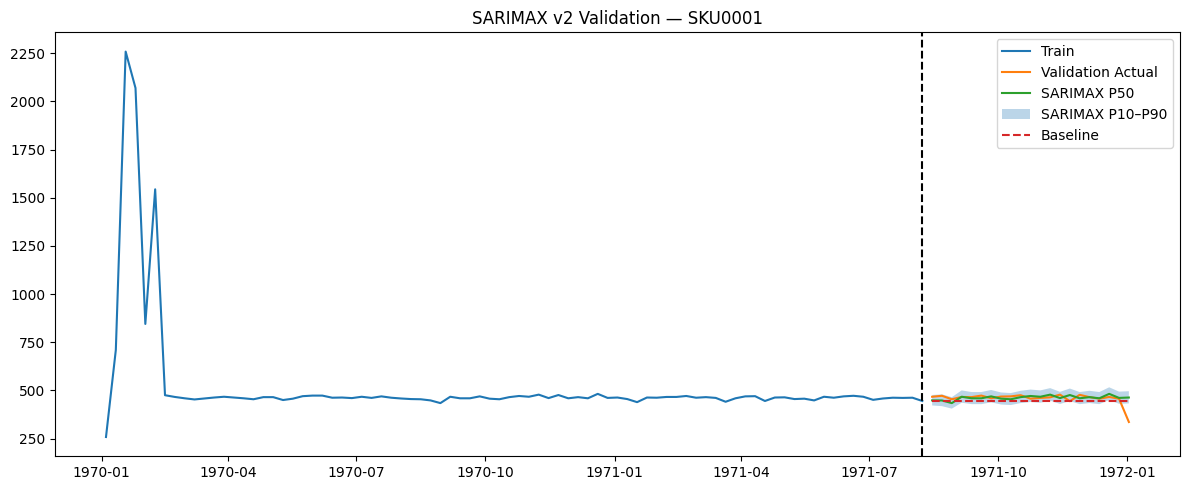

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(train_df["week"], train_df["weekly_qty"], label="Train")
plt.plot(val_df["week"], val_df["weekly_qty"], label="Validation Actual")

plt.plot(val_df["week"], val_df["p50"], label="SARIMAX P50")
plt.fill_between(
    val_df["week"],
    val_df["p10"],
    val_df["p90"],
    alpha=0.3,
    label="SARIMAX P10–P90"
)

plt.plot(val_df["week"], val_df["baseline"], linestyle="--", label="Baseline")

plt.axvline(train_df["week"].max(), linestyle="--", color="black")

plt.title(f"SARIMAX v2 Validation — {sku_id}")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
FORECAST_HORIZON = 12

future_campaign = [0.0] * FORECAST_HORIZON  # can be replaced by plan

future_pred = results.get_forecast(
    steps=FORECAST_HORIZON,
    exog=pd.DataFrame({"campaign_intensity": future_campaign})
)

future_ci = future_pred.conf_int(alpha=0.2)

future_df = pd.DataFrame({
    "p50": np.expm1(future_pred.predicted_mean),
    "p10": np.expm1(future_ci.iloc[:, 0]),
    "p90": np.expm1(future_ci.iloc[:, 1])
})

future_df


,p50,p10,p90
84,448.192962,421.833393,476.195795
85,447.713938,418.105698,479.413889
86,433.986245,405.276478,464.724805
87,466.999266,436.110569,500.070732
88,458.999964,428.639234,491.506155
89,458.999998,428.639265,491.506192
90,469.000000,437.979251,502.212850
91,457.000000,426.771270,489.364862
92,454.000000,423.969275,486.152865
93,465.000000,434.243257,497.930187


In [21]:
# Generate future week timestamps
last_week = sku_df["week"].max()

future_weeks = pd.date_range(
    start=last_week + pd.Timedelta(weeks=1),
    periods=len(future_df),
    freq="W-SUN"
)

future_df = future_df.copy()
future_df["week"] = future_weeks


In [22]:
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / f"sarimax_{sku_id}.pkl"
results.save(model_path)

print(f"Model saved at {model_path}")


Model saved at models\sarimax_SKU0001.pkl


In [ ]:

# Validate schema
required_cols = {"week", "p10", "p50", "p90"}
assert required_cols.issubset(future_df.columns), "future_df missing required forecast columns"

weekly_forecast = future_df.copy()
weekly_forecast["sku_id"] = sku_id

# Optional metadata
weekly_forecast["model_type"] = "SARIMAX"
weekly_forecast["model_version"] = "v1.0.0"

# Create artifacts directory if needed
import os
os.makedirs("../artifacts", exist_ok=True)

# Save CSV
forecast_path = "../artifacts/weekly_forecast_future.csv"
weekly_forecast.to_csv(forecast_path, index=False)

print(f"Weekly forecast saved to {forecast_path}")

weekly_forecast.head()


Weekly forecast saved to ../artifacts/weekly_forecast_future.csv


,p50,p10,p90,week,sku_id,model_type,model_version
84,448.192962,421.833393,476.195795,1972-01-09,SKU0001,SARIMAX,v1.0.0
85,447.713938,418.105698,479.413889,1972-01-16,SKU0001,SARIMAX,v1.0.0
86,433.986245,405.276478,464.724805,1972-01-23,SKU0001,SARIMAX,v1.0.0
87,466.999266,436.110569,500.070732,1972-01-30,SKU0001,SARIMAX,v1.0.0
88,458.999964,428.639234,491.506155,1972-02-06,SKU0001,SARIMAX,v1.0.0
